In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

Загрузка и фильтрация одной точки

In [21]:

df = pd.read_csv('/home/nursss/Документы/updated_data.csv')

df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time")
df = df.set_index("time")

print("Общее количество строк:", len(df))
print("Диапазон дат:", df.index.min(), "—", df.index.max())

# Смотрим уникальные точки
unique_points = df[["latitude", "longitude"]].drop_duplicates()
print("Количество уникальных точек:", len(unique_points))

Общее количество строк: 321584
Диапазон дат: 2013-01-01 00:00:00 — 2013-12-31 00:00:00
Количество уникальных точек: 1166


Создание полного daily индекса и интерполяция

In [22]:
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time")

# Список уникальных точек
unique_points = df[["latitude", "longitude"]].drop_duplicates()

processed_dfs = []

for _, row in unique_points.iterrows():
    lat, lon = row["latitude"], row["longitude"]
    df_point = df[(df["latitude"] == lat) & (df["longitude"] == lon)].copy()
    df_point = df_point.set_index("time")

    # Полный daily индекс для этой точки
    full_range = pd.date_range(start=df_point.index.min(),
                               end=df_point.index.max(),
                               freq="D")
    df_point = df_point.reindex(full_range)

    # Интерполяция временных признаков
    df_point["sm_tgt"] = df_point["sm_tgt"].interpolate()
    df_point["sm_aux"] = df_point["sm_aux"].interpolate()

    # Гранулометрия — заполнение вперёд
    df_point["clay_content"] = df_point["clay_content"].ffill()
    df_point["sand_content"] = df_point["sand_content"].ffill()
    df_point["silt_content"] = df_point["silt_content"].ffill()

    # Сохраняем координаты
    df_point["latitude"] = lat
    df_point["longitude"] = lon

    processed_dfs.append(df_point)

# Объединяем все точки в один DataFrame
df_all = pd.concat(processed_dfs)
df_all = df_all.sort_index()

print("После выравнивания:", len(df_all))
print("Пропуски:\n", df_all.isnull().sum())

KeyError: 'time'

График временного ряда

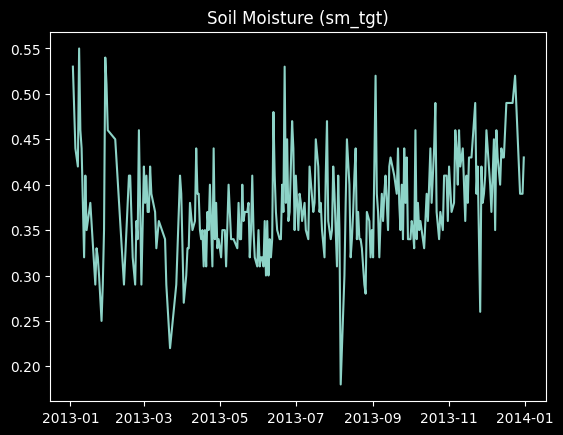

In [6]:
plt.figure()
plt.plot(df_point["sm_tgt"])
plt.title("Soil Moisture (sm_tgt)")
plt.show()

Подготовка признаков

Выбираем порядок столбцов (цель первой):

In [7]:
features = ["sm_tgt", "sm_aux",
            "clay_content", "sand_content", "silt_content"]

data = df_point[features].values

Создание последовательностей

In [9]:
def create_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i])
        y.append(data[i, 0])  # sm_tgt — первый столбец
    return np.array(X), np.array(y)

window = 24
X, y = create_sequences(data, window)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (339, 24, 5)
y shape: (339,)


Train / Val / Test split (без shuffle)

In [10]:
train_size = int(0.7 * len(X))
val_size = int(0.85 * len(X))

X_train, X_val, X_test = X[:train_size], X[train_size:val_size], X[val_size:]
y_train, y_val, y_test = y[:train_size], y[train_size:val_size], y[val_size:]

Масштабирование (только по train)

In [12]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# reshape для fit
X_train_reshaped = X_train.reshape(-1, X_train.shape[2])
scaler_X.fit(X_train_reshaped)

scaler_y.fit(y_train.reshape(-1, 1))

def scale_X(X):
    X_reshaped = X.reshape(-1, X.shape[2])
    X_scaled = scaler_X.transform(X_reshaped)
    return X_scaled.reshape(X.shape)

X_train = scale_X(X_train)
X_val = scale_X(X_val)
X_test = scale_X(X_test)

y_train = scaler_y.transform(y_train.reshape(-1, 1))
y_val = scaler_y.transform(y_val.reshape(-1, 1))
y_test = scaler_y.transform(y_test.reshape(-1, 1))

Построение LSTM модели

In [15]:
model = Sequential([
    LSTM(64, input_shape=(window, X_train.shape[2])),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])

early_stop = EarlyStopping(patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=16,
    callbacks=[early_stop]
)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.1429 - mae: 0.3184 - val_loss: 0.0566 - val_mae: 0.2177
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0375 - mae: 0.1494 - val_loss: 0.0171 - val_mae: 0.0963
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0264 - mae: 0.1190 - val_loss: 0.0133 - val_mae: 0.0990
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0222 - mae: 0.1094 - val_loss: 0.0113 - val_mae: 0.0851
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0216 - mae: 0.1114 - val_loss: 0.0115 - val_mae: 0.0862
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0220 - mae: 0.1106 - val_loss: 0.0115 - val_mae: 0.0869
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0222 - mae: 0.1130 - val_loss: 0.0114 - val_mae: 0.0872
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0209 - mae: 0.1068 - val_loss: 0.0114 - val_mae: 0.0900
Epoch 9/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.019

Оценка модели

In [16]:
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step
MAE: 0.11070181718319322
RMSE: 0.13424175678335012


In [17]:
# baseline: предыдущий день
naive_pred = X_test[:, -1, 0]  # последний sm_tgt в окне
naive_pred = scaler_y.inverse_transform(naive_pred.reshape(-1,1))

mae_naive = mean_absolute_error(y_true, naive_pred)

print("MAE LSTM:", mae)
print("MAE Naive:", mae_naive)

MAE LSTM: 0.11070181718319322
MAE Naive: 0.09121621621621621


Сравнение с naive baseline

In [18]:
# baseline: предыдущий день
naive_pred = X_test[:, -1, 0]  # последний sm_tgt в окне
naive_pred = scaler_y.inverse_transform(naive_pred.reshape(-1,1))

mae_naive = mean_absolute_error(y_true, naive_pred)

print("MAE LSTM:", mae)
print("MAE Naive:", mae_naive)

MAE LSTM: 0.11070181718319322
MAE Naive: 0.09121621621621621


Визуальное сравнение

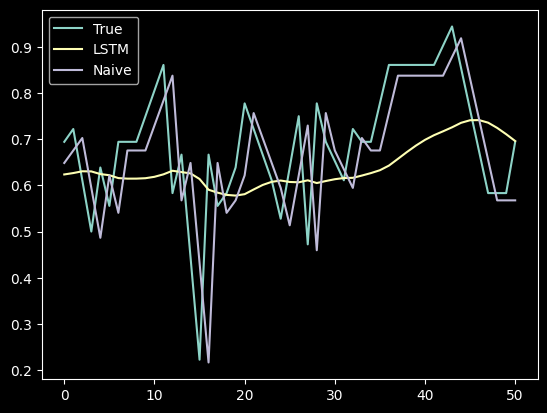

In [19]:

plt.figure()
plt.plot(y_true, label="True")
plt.plot(y_pred, label="LSTM")
plt.plot(naive_pred, label="Naive")
plt.legend()
plt.show()